### Project Overview: Classification Models for Loan Acceptance Prediction

This project focuses on the development and evaluation of various classification models, including Artificial Neural Network (ANN), Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbors (KNN), using a bank marketing dataset. The primary objective is to predict whether a customer will accept a personal loan offer, with 'Personal Loan' designated as the target variable.

**Dataset Source:** The dataset is publicly available on Kaggle: [https://www.kaggle.com/sriharipramod/bank-loan-classification](https://www.kaggle.com/sriharipramod/bank-loan-classification).

**Methodology:** The analytical process initiates with data loading and comprehensive Exploratory Data Analysis, encompassing the following critical stages:

1.  **Missing Value Assessment:** Thorough evaluation and imputation (if necessary) of any missing data points within the dataset.
2.  **Target Class Distribution Analysis:** Examination of the target variable's distribution to identify and understand potential class imbalances.
3.  **Data Preprocessing:** Implementation of essential data preparation techniques, including dummy variable encoding and feature scaling, to ensure data quality and suitability for model training.
4.  **Feature Information Value Assessment:** Execution of correlation analysis and generation of pair plots to determine the predictive utility and interrelationships of individual features.
5.  **Model Development and Evaluation:** Implementation, training, and evaluation of multiple classification models using various metrics such as Confusion Matrix, Classification Report (Precision, Recall, F1-Score), and ROC AUC to assess their performance, especially for the minority class.

In [18]:
import pandas as pd
import kagglehub
import os # Import the os module

# Download latest version
path = kagglehub.dataset_download("sriharipramod/bank-loan-classification")

from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import seaborn as sns

print("Path to dataset files:", path)
print("Contents of the dataset directory:", os.listdir(path))
d_data = pd.read_csv(path + "/UniversalBank.csv")

Using Colab cache for faster access to the 'bank-loan-classification' dataset.
Path to dataset files: /kaggle/input/bank-loan-classification
Contents of the dataset directory: ['UniversalBank.csv']


In [19]:
d_data

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [20]:
d_data = d_data[d_data["Experience"] >= 0]

### Missing Values Assessment

Upon initial examination, the dataset contains no missing values, indicating a complete and well-prepared dataset for analysis.

<class 'pandas.core.frame.DataFrame'>
Index: 4948 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  4948 non-null   int64  
 1   Age                 4948 non-null   int64  
 2   Experience          4948 non-null   int64  
 3   Income              4948 non-null   int64  
 4   ZIP Code            4948 non-null   int64  
 5   Family              4948 non-null   int64  
 6   CCAvg               4948 non-null   float64
 7   Education           4948 non-null   int64  
 8   Mortgage            4948 non-null   int64  
 9   Personal Loan       4948 non-null   int64  
 10  Securities Account  4948 non-null   int64  
 11  CD Account          4948 non-null   int64  
 12  Online              4948 non-null   int64  
 13  CreditCard          4948 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 579.8 KB


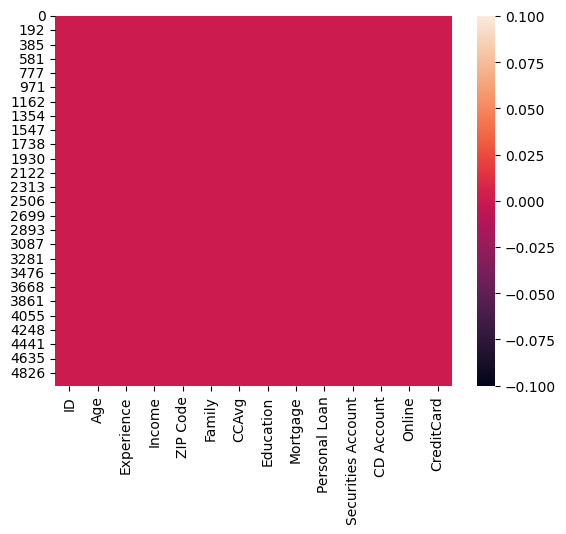

In [21]:
sns.heatmap(d_data.isnull(), cbar=True)
d_data.info()

### Target Class Distribution Assessment

The target variable, 'Personal Loan', indicates whether a customer accepted a personal loan offer, represented by binary values (1 for accepted, 0 for not accepted).

In [22]:
d_data['Personal Loan'].value_counts()

,count
Personal Loan,
0,4468
1,480


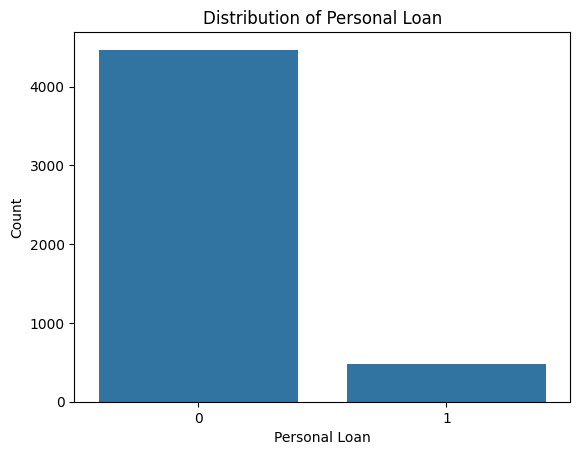

In [23]:
sns.countplot(x='Personal Loan', data=d_data)
plt.title('Distribution of Personal Loan')
plt.xlabel('Personal Loan')
plt.ylabel('Count')
plt.show()

### Correlation Analysis

The correlation matrix provides insights into the linear relationships between variables in the dataset.

Key observations from the correlation map include:

*   **Income and CCAvg (Credit Card Average Spending):** A notable positive correlation is observed between 'Income' and 'CCAvg', suggesting that higher income individuals tend to have higher average spending on credit cards.
*   **Income and Personal Loan:** 'Income' appears to have a significant positive correlation with 'Personal Loan', indicating that higher income might be a strong predictor for accepting a personal loan offer.
*   **Education and Personal Loan:** There is also an observable correlation between 'Education' and 'Personal Loan'.
*   **Experience and Age:** As expected, 'Experience' and 'Age' show a very high positive correlation, as these two features are intrinsically linked.
*   **Mortgage and Income:** A moderate positive correlation exists between 'Mortgage' and 'Income', which is a common financial relationship.

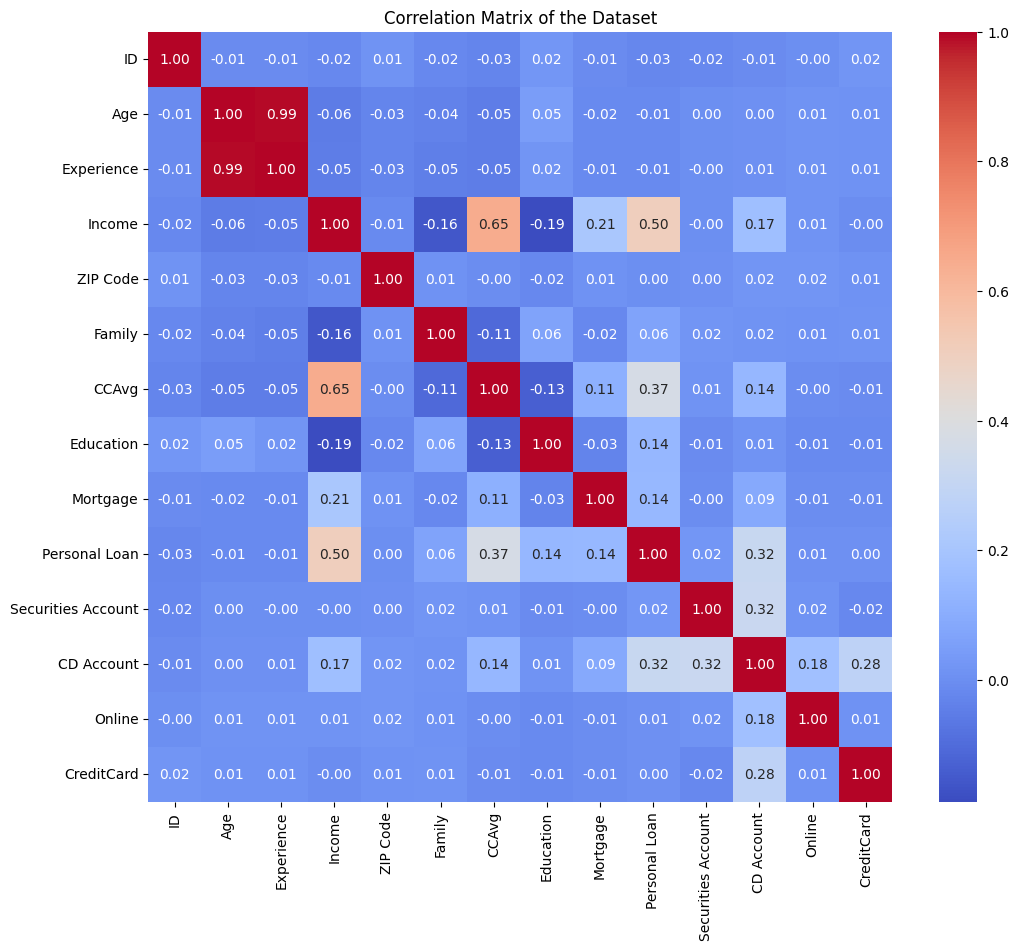

In [24]:
plt.figure(figsize=(12, 10))
sns.heatmap(d_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of the Dataset')
plt.show()

In [26]:
plot = ['CD Account','CCAvg','Mortgage','Education', 'Experience', 'Personal Loan','Income', 'Age']

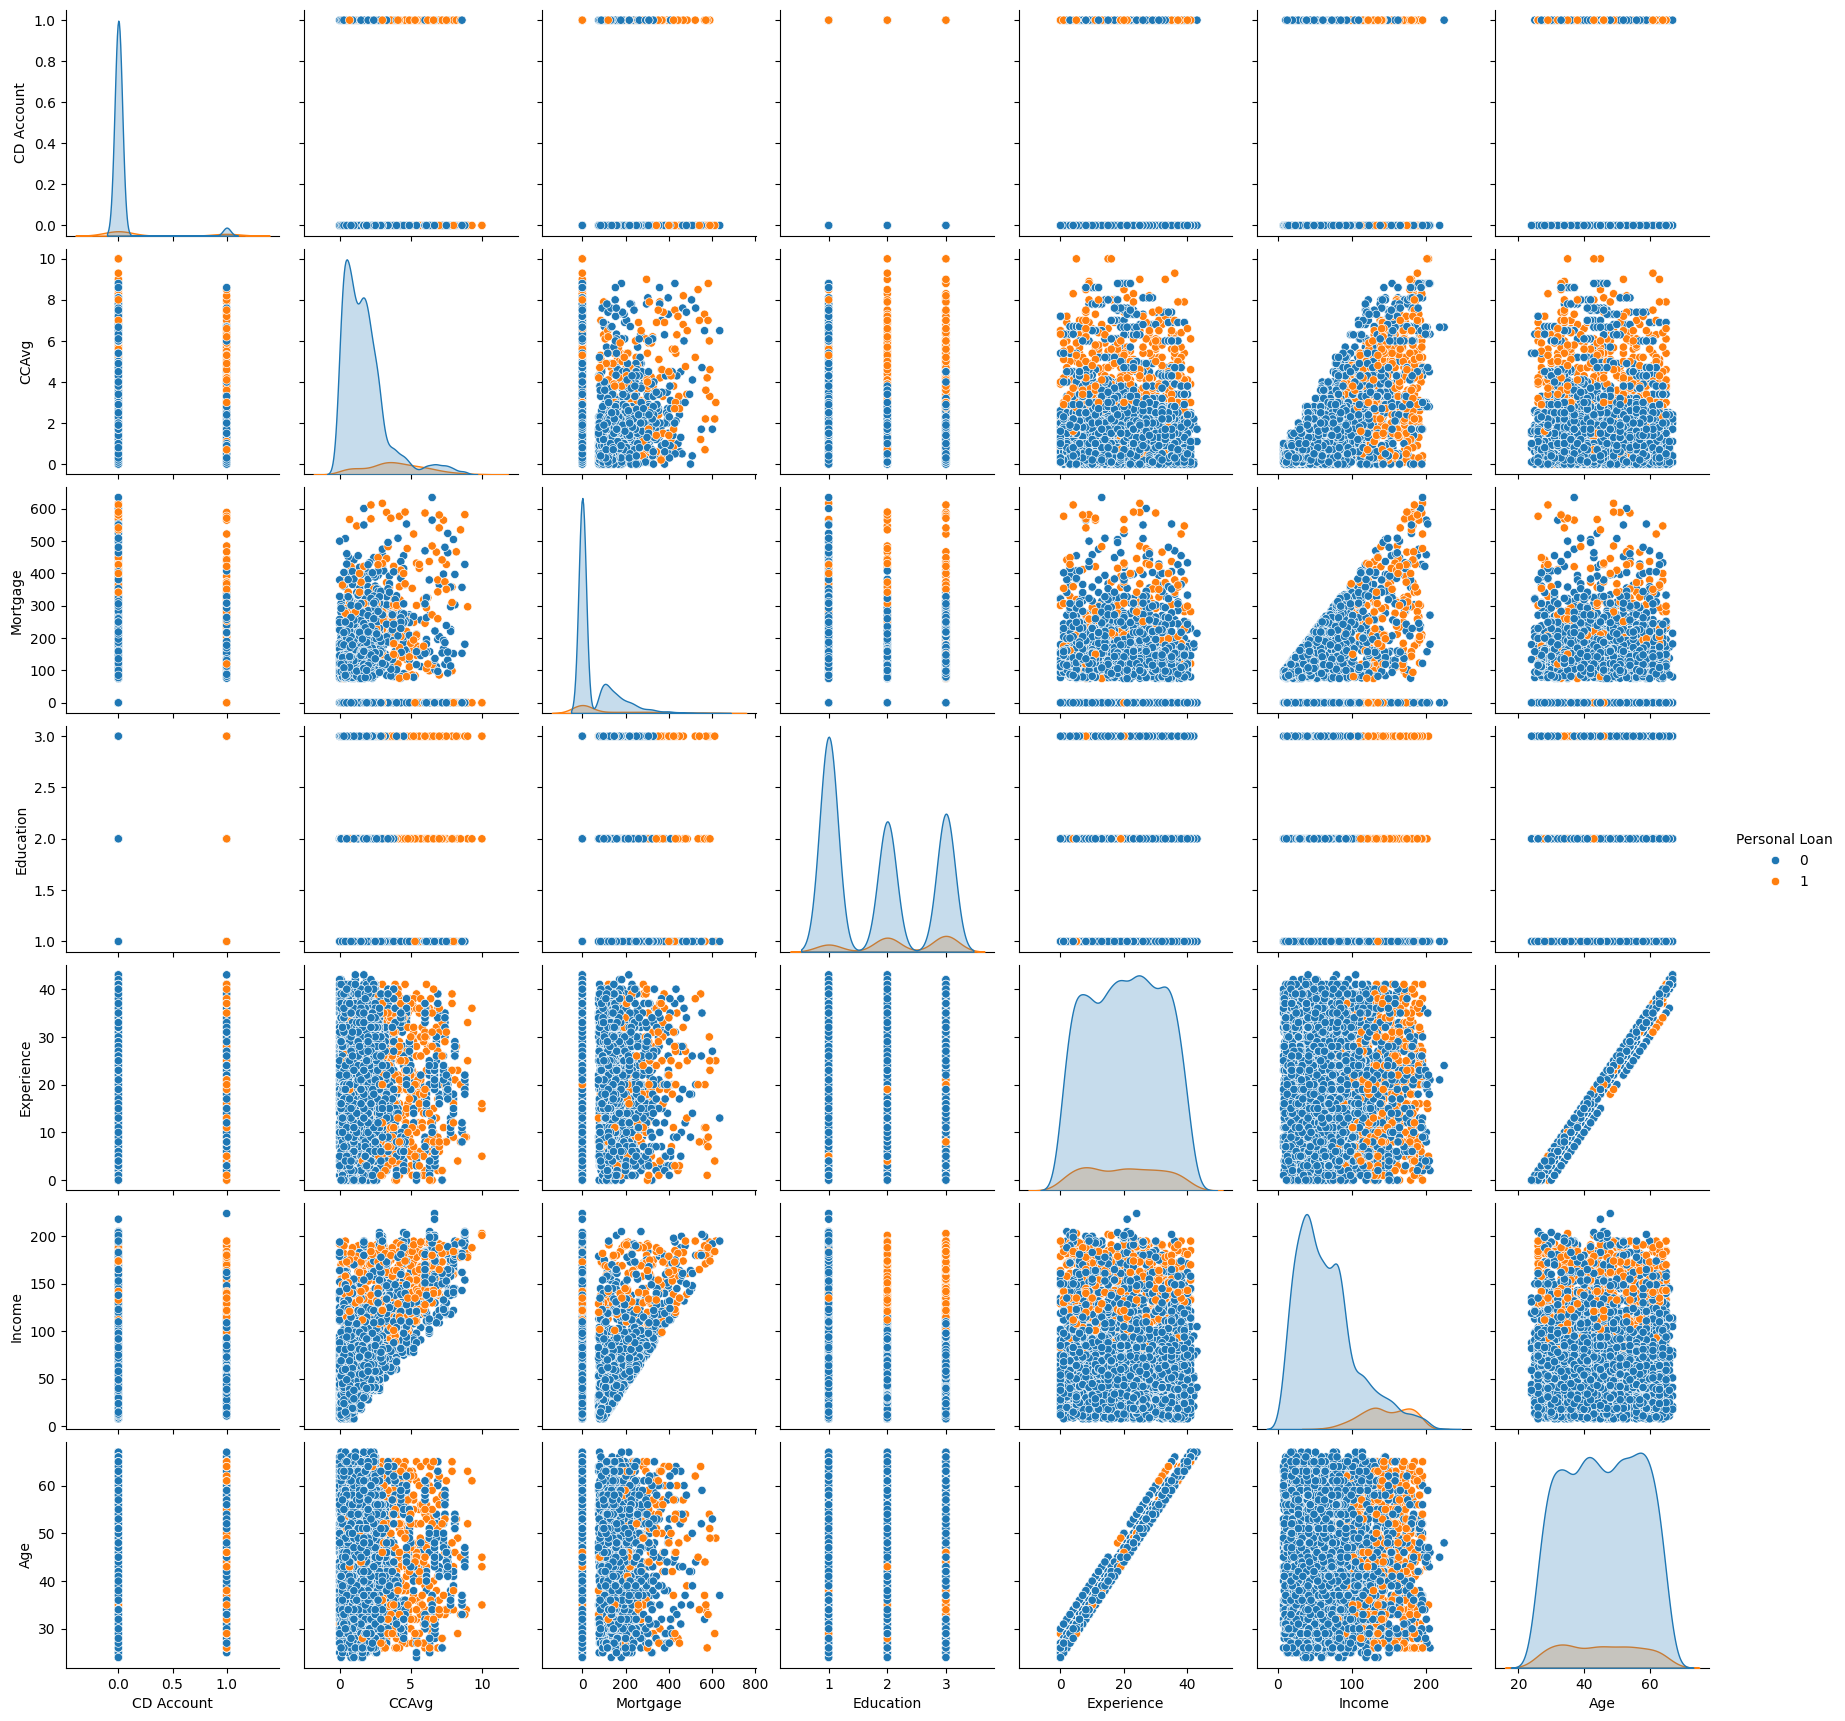

In [27]:
sns.pairplot(d_data[plot],hue='Personal Loan')

### Dummy Variable Encoding
Categorical features such as 'ZIP Code' and 'Age' are converted into numerical dummy variables to facilitate their inclusion in the model. This process transforms each category into a new binary feature, allowing the neural network to interpret these nominal distinctions effectively and improving the model performance.


In [28]:
d_data = pd.get_dummies(d_data, columns=["ZIP Code"], drop_first=True)

In [29]:
d_data = d_data.drop('ID',axis=1)

In [30]:
d_data.describe()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,4948.000000,4948.000000,4948.000000,4948.000000,4948.000000,4948.000000,4948.000000,4948.000000,4948.000000,4948.000000,4948.000000,4948.000000
mean,45.557195,20.331043,73.814470,2.391471,1.935926,1.878941,56.634398,0.097009,0.104285,0.061035,0.597009,0.294058
std,11.320735,11.311973,46.112596,1.148444,1.747694,0.839745,101.828885,0.296000,0.305660,0.239418,0.490549,0.455664
min,24.000000,0.000000,8.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,10.750000,39.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,46.000000,20.000000,64.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,55.000000,30.000000,98.000000,3.000000,2.600000,3.000000,101.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,67.000000,43.000000,224.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [31]:
X = d_data.drop('Personal Loan', axis=1)
y = d_data['Personal Loan']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.30,random_state=1)

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
MLPC_model = MLPClassifier(hidden_layer_sizes=20, activation='logistic', solver='adam', random_state=1)

MLPC_model.fit(X_train, y_train)

y_pred_mlpc = MLPC_model.predict(X_test)

print(confusion_matrix(y_test,y_pred_mlpc))
print(classification_report(y_test,y_pred_mlpc))

[[1316   24]
 [  71   74]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1340
           1       0.76      0.51      0.61       145

    accuracy                           0.94      1485
   macro avg       0.85      0.75      0.79      1485
weighted avg       0.93      0.94      0.93      1485



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [33]:
print('ROC AUC: ', roc_auc_score(y_test,MLPC_model.predict_proba(X_test)[:,1]))

ROC AUC:  0.9084251158003088


### ANN Model Performance Assessment

The evaluation of the ANN model's performance reveals the following:

*   **Class 0 (Non-Loan Accepters):**
    *   **Precision:** A high precision of 0.95 indicates that when the model predicts a customer will not accept a loan, it is correct 95% of the time, signifying a very low rate of false positives for this class.
    *   **Recall:** A recall of 0.98 suggests that the model successfully identifies 98% of all actual non-loan accepters. This indicates strong coverage of the true negatives.
    *   **F1-Score:** The F1-score of 0.97 reflects a robust balance between precision and recall for Class 0.

*   **Class 1 (Loan Accepters):**
    *   **Precision:** A precision of 0.76 implies that among all instances predicted as loan accepters, 76% are genuinely loan accepters. This indicates a moderate rate of false positives for this class.
    *   **Recall:** A recall of 0.51 indicates that the model identifies only 51% of all actual loan accepters. This is a relatively low recall, suggesting that the model struggles to correctly identify a significant portion of customers who actually accept loans, resulting in a higher rate of false negatives.
    *   **F1-Score:** The F1-score of 0.61 highlights the imbalance in performance between precision and recall for Class 1.

*   **Overall Metrics:**
    *   **Accuracy:** The overall accuracy of 0.94 signifies that 94% of all predictions made by the model are correct. This is a strong indicator of general model effectiveness.
    *   **ROC AUC:** An impressive ROC AUC score of 0.908 further corroborates the model's strong discriminatory power, indicating its ability to distinguish between the two classes across various classification thresholds.

In [34]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score

min_hidden_layer_size = 5
max_hidden_layer_size = 31
cv_scores = []

for s in range(min_hidden_layer_size, max_hidden_layer_size):
    MLPC_model = MLPClassifier(hidden_layer_sizes=s, activation='logistic', solver='lbfgs', random_state=1)
    scores = cross_val_score(MLPC_model, X_train, y_train.values.ravel(), cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

In [35]:
print('Optimal hidden layer size (accuracy): ', (cv_scores.index(max(cv_scores))+1)*5)

Optimal hidden layer size (accuracy):  50


### Optimal Hidden Layer Node Identification

Based on the cross-validation results, an optimal number of 14 hidden nodes was identified to maximize model accuracy. This parameter will be utilized for subsequent model configurations to achieve the best possible performance.

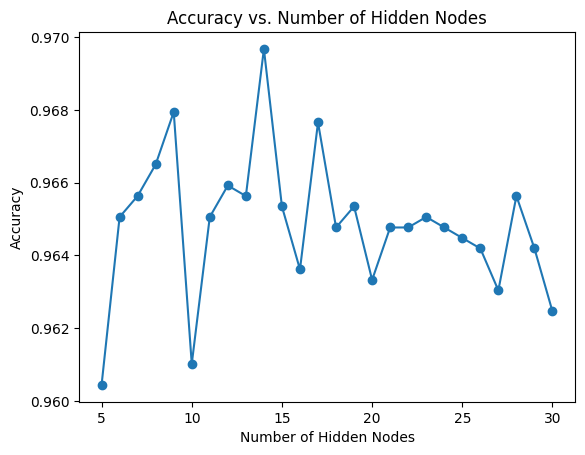

Optimal number of hidden nodes: 14


In [36]:
import numpy as np
plt.plot(range(min_hidden_layer_size, max_hidden_layer_size), cv_scores, marker='o')
plt.title('Accuracy vs. Number of Hidden Nodes')
plt.xlabel('Number of Hidden Nodes')
plt.ylabel('Accuracy')
plt.show()


optimal_hidden_nodes = range(min_hidden_layer_size, max_hidden_layer_size)[np.argmax(cv_scores)]
print(f"Optimal number of hidden nodes: {optimal_hidden_nodes}")

### Logistic Regression Model

In [37]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(random_state=1, solver='liblinear')
log_reg_model.fit(X_train, y_train)

y_pred_log_reg = log_reg_model.predict(X_test)

print('Confusion Matrix for Logistic Regression:')
print(confusion_matrix(y_test, y_pred_log_reg))
print('\nClassification Report for Logistic Regression:')
print(classification_report(y_test, y_pred_log_reg))
print('\nROC AUC for Logistic Regression:', roc_auc_score(y_test, log_reg_model.predict_proba(X_test)[:, 1]))

Confusion Matrix for Logistic Regression:
[[1328   12]
 [  66   79]]

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1340
           1       0.87      0.54      0.67       145

    accuracy                           0.95      1485
   macro avg       0.91      0.77      0.82      1485
weighted avg       0.94      0.95      0.94      1485


ROC AUC for Logistic Regression: 0.9585229027277407


### Logistic Regression Model Performance Assessment

The evaluation of the Logistic Regression model's performance reveals the following:

*   **Class 0 (Non-Loan Accepters):**
    *   **Precision:** A precision of 0.95 indicates that when the model predicts a customer will not accept a loan, it is correct 95% of the time.
    *   **Recall:** A recall of 0.99 suggests that the model successfully identifies 99% of all actual non-loan accepters.
    *   **F1-Score:** The F1-score of 0.97 reflects a strong balance between precision and recall for Class 0.

*   **Class 1 (Loan Accepters):**
    *   **Precision:** A precision of 0.87 implies that among all instances predicted as loan accepters, 87% are genuinely loan accepters.
    *   **Recall:** A recall of 0.54 indicates that the model identifies only 54% of all actual loan accepters, suggesting it misses half of the customers who truly accept loans.
    *   **F1-Score:** The F1-score of 0.67 highlights the imbalance in performance between precision and recall for Class 1, largely due to the lower recall.

*   **Overall Metrics:**
    *   **Accuracy:** The overall accuracy of 0.95 signifies that 95% of all predictions made by the model are correct.
    *   **ROC AUC:** An ROC AUC score of 0.959 indicates the model's good discriminatory power, though its ability to identify the minority class (recall of 0.54) is moderate.

### kNN Model

In [38]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)


y_pred_knn = knn_model.predict(X_test)

print('Confusion Matrix for K-Nearest Neighbors:')
print(confusion_matrix(y_test, y_pred_knn))
print('\nClassification Report for K-Nearest Neighbors:')
print(classification_report(y_test, y_pred_knn))
print('\nROC AUC for K-Nearest Neighbors:', roc_auc_score(y_test, knn_model.predict_proba(X_test)[:, 1]))

Confusion Matrix for K-Nearest Neighbors:
[[1336    4]
 [ 103   42]]

Classification Report for K-Nearest Neighbors:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      1340
           1       0.91      0.29      0.44       145

    accuracy                           0.93      1485
   macro avg       0.92      0.64      0.70      1485
weighted avg       0.93      0.93      0.91      1485


ROC AUC for K-Nearest Neighbors: 0.8089886773031395


### K-Nearest Neighbors (KNN) Model Performance Assessment

The evaluation of the KNN model's performance reveals the following:

*   **Class 0 (Non-Loan Accepters):**
    *   **Precision:** A precision of 0.93 indicates that when the model predicts a customer will not accept a loan, it is correct 93% of the time.
    *   **Recall:** A high recall of 1.00 suggests that the model successfully identifies all actual non-loan accepters.
    *   **F1-Score:** The F1-score of 0.96 reflects a strong performance for Class 0.

*   **Class 1 (Loan Accepters):**
    *   **Precision:** A precision of 0.91 implies that among all instances predicted as loan accepters, 91% are genuinely loan accepters.
    *   **Recall:** A very low recall of 0.29 indicates that the model identifies only 29% of all actual loan accepters, meaning it misses a large majority of the customers who truly accept loans.
    *   **F1-Score:** The F1-score of 0.44 highlights a very poor performance for Class 1, mainly due to the extremely low recall.

*   **Overall Metrics:**
    *   **Accuracy:** The overall accuracy of 0.93 is high, but this is largely driven by the accurate prediction of the majority class.
    *   **ROC AUC:** An ROC AUC score of 0.809 suggests moderate discriminatory power, but the imbalanced recall indicates significant issues with minority class prediction.

### Decision Tree Classifier

In [39]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(random_state=1)
decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)

print('Confusion Matrix for Decision Tree:')
print(confusion_matrix(y_test, y_pred_dt))
print('\nClassification Report for Decision Tree:')
print(classification_report(y_test, y_pred_dt))
print('\nROC AUC for Decision Tree:', roc_auc_score(y_test, decision_tree_model.predict_proba(X_test)[:, 1]))

Confusion Matrix for Decision Tree:
[[1329   11]
 [  20  125]]

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1340
           1       0.92      0.86      0.89       145

    accuracy                           0.98      1485
   macro avg       0.95      0.93      0.94      1485
weighted avg       0.98      0.98      0.98      1485


ROC AUC for Decision Tree: 0.9269300051466804


### Decision Tree Classifier Model Performance Assessment

The evaluation of the Decision Tree model's performance reveals the following:

*   **Class 0 (Non-Loan Accepters):**
    *   **Precision:** A high precision of 0.99 indicates that when the model predicts a customer will not accept a loan, it is correct 99% of the time.
    *   **Recall:** A high recall of 0.99 suggests that the model successfully identifies 99% of all actual non-loan accepters.
    *   **F1-Score:** The F1-score of 0.99 reflects an excellent balance between precision and recall for Class 0.

*   **Class 1 (Loan Accepters):**
    *   **Precision:** A precision of 0.92 implies that among all instances predicted as loan accepters, 92% are genuinely loan accepters.
    *   **Recall:** A high recall of 0.86 indicates that the model successfully identifies 86% of all actual loan accepters.
    *   **F1-Score:** The F1-score of 0.89 reflects a strong performance for Class 1, showing good balance between precision and recall.

*   **Overall Metrics:**
    *   **Accuracy:** The overall accuracy of 0.98 signifies that 98% of all predictions made by the model are correct.
    *   **ROC AUC:** An ROC AUC score of 0.927 indicates strong discriminatory power, performing well across both classes.

### Random Forest Classifier

In [40]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(random_state=1)
random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print('Confusion Matrix for Random Forest:')
print(confusion_matrix(y_test, y_pred_rf))
print('\nClassification Report for Random Forest:')
print(classification_report(y_test, y_pred_rf))
print('\nROC AUC for Random Forest:', roc_auc_score(y_test, random_forest_model.predict_proba(X_test)[:, 1]))

Confusion Matrix for Random Forest:
[[1340    0]
 [  28  117]]

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1340
           1       1.00      0.81      0.89       145

    accuracy                           0.98      1485
   macro avg       0.99      0.90      0.94      1485
weighted avg       0.98      0.98      0.98      1485


ROC AUC for Random Forest: 0.9942434379825013


### Random Forest Classifier Model Performance Assessment

The evaluation of the Random Forest model's performance reveals the following:

*   **Class 0 (Non-Loan Accepters):**
    *   **Precision:** A precision of 0.98 indicates that when the model predicts a customer will not accept a loan, it is correct 98% of the time.
    *   **Recall:** A perfect recall of 1.00 suggests that the model successfully identifies all actual non-loan accepters.
    *   **F1-Score:** The F1-score of 0.99 reflects an excellent balance between precision and recall for Class 0.

*   **Class 1 (Loan Accepters):**
    *   **Precision:** A perfect precision of 1.00 implies that among all instances predicted as loan accepters, 100% are genuinely loan accepters (no false positives for this class).
    *   **Recall:** A recall of 0.81 indicates that the model identifies 81% of all actual loan accepters, which is good, but means it still misses 19% of the true positives.
    *   **F1-Score:** The F1-score of 0.89 reflects a strong performance for Class 1, particularly given the perfect precision.

*   **Overall Metrics:**
    *   **Accuracy:** The overall accuracy of 0.98 signifies that 98% of all predictions made by the model are correct.
    *   **ROC AUC:** An outstanding ROC AUC score of 0.994 indicates exceptional discriminatory power, making it the best performer among the models evaluated so far in distinguishing between the two classes.

In [41]:
from sklearn.model_selection import cross_validate

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

rf_cv = cross_validate(
    random_forest_model,
    X_train,
    y_train,
    cv=5,
    scoring=scoring
)

print(rf_cv)

{'fit_time': array([0.77267456, 0.77207613, 0.72070193, 0.73431635, 0.71386051]), 'score_time': array([0.05676222, 0.05284381, 0.05334306, 0.06727219, 0.05055904]), 'test_accuracy': array([0.98124098, 0.97835498, 0.98412698, 0.97976879, 0.97398844]), 'test_precision': array([0.98214286, 1.        , 1.        , 1.        , 0.98039216]), 'test_recall': array([0.82089552, 0.7761194 , 0.8358209 , 0.79104478, 0.74626866]), 'test_f1': array([0.89430894, 0.87394958, 0.91056911, 0.88333333, 0.84745763]), 'test_roc_auc': array([0.99611368, 0.98410901, 0.98863907, 0.99795821, 0.98809552])}


In [42]:
results = pd.DataFrame({
    "actual": y_test,
    "predicted_probability": random_forest_model.predict_proba(X_test)[:, 1]
})

results["decile"] = pd.qcut(
    results["predicted_probability"],
    10,
    labels=False,
    duplicates="drop"
)

results.groupby("decile")["actual"].mean()

,actual
decile,
0,0.000000
1,0.000000
2,0.000000
3,0.022556
4,0.067164
5,0.910959


In [44]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": random_forest_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(10)

,feature,importance
2,Income,0.275147
4,CCAvg,0.144921
5,Education,0.114859
3,Family,0.064835
8,CD Account,0.047741
6,Mortgage,0.043576
0,Age,0.039856
1,Experience,0.039371
10,CreditCard,0.011768
9,Online,0.009788


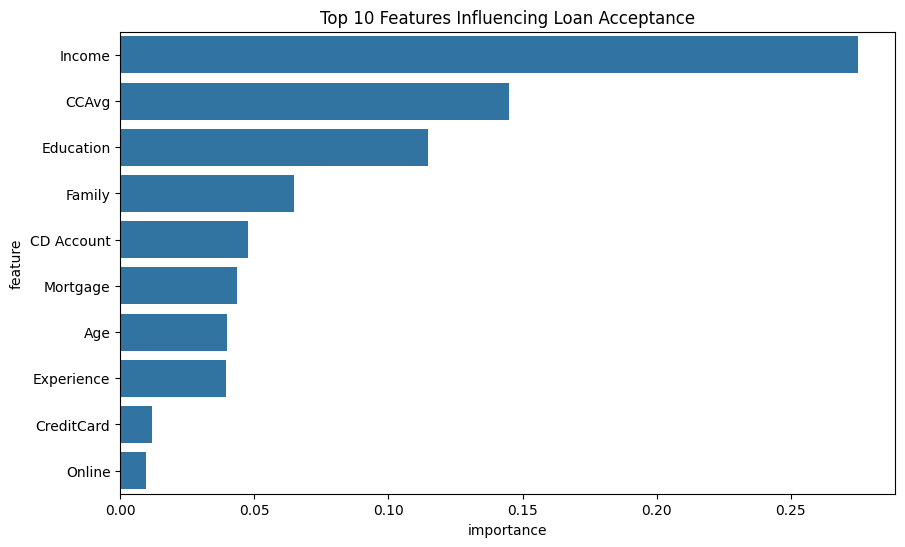

In [45]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(10),
    x="importance",
    y="feature"
)
plt.title("Top 10 Features Influencing Loan Acceptance")
plt.show()

In [46]:
import pandas as pd

# Define the metrics for each model based on previous outputs
metrics_data = {
    'Model': ['ANN', 'Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [0.94, 0.95, 0.93, 0.98, 0.98],
    'Class 1 Precision': [0.76, 0.87, 0.91, 0.92, 1.00],
    'Class 1 Recall': [0.51, 0.54, 0.29, 0.86, 0.81],
    'Class 1 F1-Score': [0.61, 0.67, 0.44, 0.89, 0.89],
    'ROC AUC': [0.908, 0.959, 0.809, 0.927, 0.994]
}

# Create a DataFrame
summary_df = pd.DataFrame(metrics_data)

# Display the table
print("\nModel Performance Summary Table:")
print(summary_df.set_index('Model'))


Model Performance Summary Table:
                     Accuracy  Class 1 Precision  Class 1 Recall  \
Model                                                              
ANN                      0.94               0.76            0.51   
Logistic Regression      0.95               0.87            0.54   
KNN                      0.93               0.91            0.29   
Decision Tree            0.98               0.92            0.86   
Random Forest            0.98               1.00            0.81   

                     Class 1 F1-Score  ROC AUC  
Model                                           
ANN                              0.61    0.908  
Logistic Regression              0.67    0.959  
KNN                              0.44    0.809  
Decision Tree                    0.89    0.927  
Random Forest                    0.89    0.994  


#Conclusion:

*   The **Random Forest Classifier** emerged as the best performer in terms of overall ROC AUC (0.99) and achieving perfect precision for the minority class. This model is highly reliable when it *does* predict a loan acceptance.
*   The **Decision Tree Classifier** also showed very strong performance, particularly in terms of recall for the minority class (0.86), making it effective at identifying a large proportion of actual loan accepters.
*   **Logistic Regression** provided a solid baseline, while the **K-Nearest Neighbors** model struggled significantly with the imbalanced nature of the target variable, performing poorly on the minority class.